# **1 Sample**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Experience và Education
X = np.array([[3, 12], [4, 13], [5, 14], [6, 15]])

# Thêm cột bias
X_bias = np.c_[np.ones(X.shape[0]), X]

# Salary thực tế
y = np.array([60, 55, 66, 93])

# [b, w1, w2] - khởi tạo tham số
theta = np.array([10, 3, 2])

print(f'Input shape: {X_bias.shape}')
print(f'Output shape: {y.shape}')
print(f'Theta shape: {theta.shape}')

Input shape: (4, 3)
Output shape: (4,)
Theta shape: (3,)


In [2]:
X_bias[1, :]

array([ 1.,  4., 13.])

In [3]:
def predict(X, theta):
    return X.dot(theta)

def compute_loss(y_hat, y):

    return (y_hat - y) ** 2

def compute_gradient(y_hat, y, X):

    return 2 * X * (y_hat - y)

def update_gradient(theta, gradient, lr):
    theta = theta - lr * gradient
    return theta

In [4]:
# Before training prediction
X_test = np.array([[1, 4, 13]])
y_hat = predict(X_test, theta)
loss = compute_loss(y_hat, y)
print(f'Loss before training: {loss}')

Loss before training: [ 144   49  324 2025]


In [5]:
epoch_max = 4
lr = 0.001  # Learning rate
N = len(y)
losses = []

for epoch in range(epoch_max):
    epoch_losses = []
    for idx in range(N):
        # Lấy mẫu dữ liệu thứ idx
        X_i = X_bias[idx, :]
        y_i = y[idx]

        # Dự đoán giá trị
        y_hat = predict(X_i, theta)

        # Tính Loss (MSE) - Chia cho N
        loss = compute_loss(y_hat, y_i)
        epoch_losses.append(loss)

        # Tính gradient
        gradient = compute_gradient(y_hat, y_i, X_i)

        # Cập nhật tham số
        theta = update_gradient(theta, gradient, lr)

    epoch_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(epoch_loss)
    print(f'Epoch {epoch+1}: Loss = {epoch_loss}, theta = {theta}')

final_theta = theta
losses, final_theta

Epoch 1: Loss = 234.6004982265337, theta = [10.09833181  3.47050512  3.35549142]
Epoch 2: Loss = 130.86470802439825, theta = [10.10382489  3.56374101  3.49816499]
Epoch 3: Loss = 138.41841820731048, theta = [10.09861696  3.61319006  3.50074271]
Epoch 4: Loss = 139.08577029797192, theta = [10.09220039  3.65739307  3.48719661]


([np.float64(234.6004982265337),
  np.float64(130.86470802439825),
  np.float64(138.41841820731048),
  np.float64(139.08577029797192)],
 array([10.09220039,  3.65739307,  3.48719661]))

In [6]:
# After training prediction
X_test = np.array([[1, 4, 13]])
y_hat = predict(X_test, final_theta)
loss = compute_loss(y_hat, y)
print(f'Loss after training: {loss}')

Loss after training: [101.10963271 226.66291844  16.44568983 526.4579469 ]


In [7]:
losses

[np.float64(234.6004982265337),
 np.float64(130.86470802439825),
 np.float64(138.41841820731048),
 np.float64(139.08577029797192)]

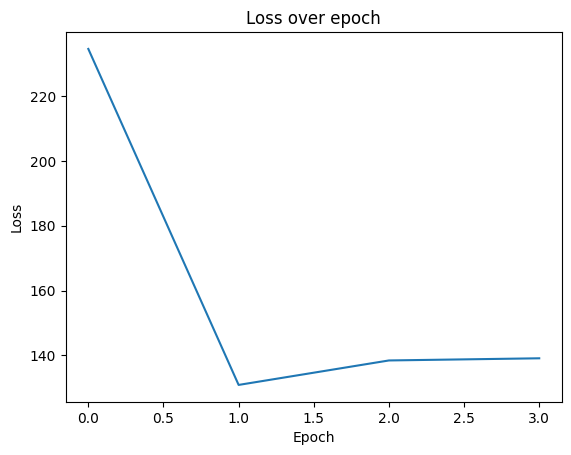

In [8]:
plt.plot(losses)
plt.title('Loss over epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# **N Sample**

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Experience và Education
X = np.array([[3, 12], [4, 13], [5, 14], [6, 15]])

# Thêm cột bias
X_bias = np.c_[np.ones(X.shape[0]), X]

# Salary thực tế
y = np.array([60, 55, 66, 93])

# [b, w1, w2] - khởi tạo tham số
theta = np.array([10, 3, 2])

print(f'Input shape: {X_bias.shape}')
print(f'Output shape: {y.shape}')
print(f'Theta shape: {theta.shape}')

Input shape: (4, 3)
Output shape: (4,)
Theta shape: (3,)


In [12]:
y_hat = predict(X_bias, theta)

In [24]:
k =  2 * (y_hat - y)
X_bias.T.shape

(3, 4)

In [27]:
def predict(X, theta):
    return X.dot(theta)

def compute_loss(y_hat, y):
    N = y.shape[0]

    return sum((y_hat - y)**2) / N

def compute_gradient(y_hat, y, X):
    k = 2 * (y_hat - y)
    return X.T.dot(k) / N

def update_gradient(theta, gradient, lr):
    theta = theta - lr * gradient
    return theta

In [28]:
# Before training prediction
X_test = np.array([[1, 4, 13]])
y_hat = predict(X_test, theta)
loss = compute_loss(y_hat, y)
print(f'Loss before training: {loss}')

Loss before training: 635.5


In [29]:
# Các thông số huấn luyện
epoch_max = 4
lr = 0.001  # Learning rate
N = len(y)
losses = []

# Huấn luyện qua các epoch
for epoch in range(epoch_max):
    # Dự đoán giá trị
    y_hat = predict(X_bias, theta)

    # Tính Loss (MSE) - Chia cho N
    loss = compute_loss(y_hat, y)
    losses.append(loss)

    # Tính gradient
    gradient = compute_gradient(y_hat, y, X_bias)

    # Cập nhật tham số
    theta = update_gradient(theta, gradient, lr)

    print(f'Epoch {epoch+1}: Loss = {loss}, theta = {theta}')

final_theta = theta
losses, final_theta

Epoch 1: Loss = 433.0, theta = [10.036  3.177  2.501]
Epoch 2: Loss = 207.64782100000002, theta = [10.056808  3.283941  2.795213]
Epoch 3: Loss = 129.43427922136902, theta = [10.06866816  3.34961385  2.96762733]
Epoch 4: Loss = 102.26797535859747, theta = [10.07525837  3.39097666  3.06830194]


([np.float64(433.0),
  np.float64(207.64782100000002),
  np.float64(129.43427922136902),
  np.float64(102.26797535859747)],
 array([10.07525837,  3.39097666,  3.06830194]))

In [30]:
# After training prediction
X_test = np.array([[1, 4, 13]])
y_hat = predict(X_test, theta)
loss = compute_loss(y_hat, y)
print(f'Loss after training: {loss}')

Loss after training: 239.97983168947812


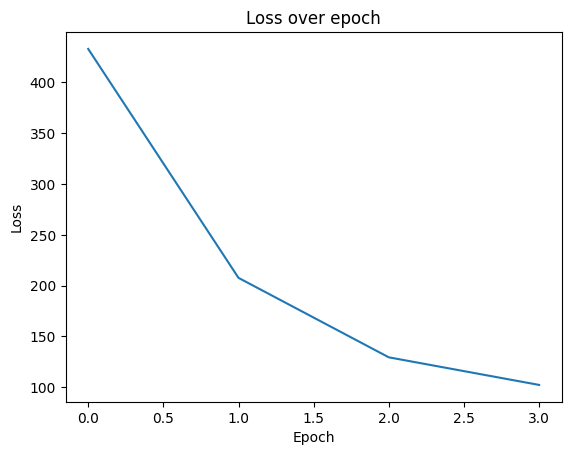

In [31]:
plt.plot(losses)
plt.title('Loss over epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()